# Overlap-based interaction criterion

We define interacting neighbors through the normalized overlap

$$
\xi_{ij}=\frac{I_{ij}}{I_{ij}^{\max}},
$$

which accounts for cell separation, shape, and relative orientation.

We adopt the criterion

$$
\xi_{ij}>e^{-1}.
$$

The same threshold is used to accept elongations: a proposed configuration is accepted only if no neighboring cell exceeds this value.

This notebook motivates the threshold by comparing the overlap with geometric contact for round and elongated cells with aspect ratio 2.7. No additional cutoff based on the sum of major semi-axes is imposed. A spatial grid is used to identify candidate pairs.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


# Figure directory
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


# Cell geometry
RADIUS = 1.0
MAX_ASPECT_RATIO = 2.7

# Shared threshold for interactions and proposed elongations
NORMALIZED_OVERLAP_THRESHOLD = np.exp(-1)

def save_figure(fig, stem):
    """Save one figure in vector and raster formats."""
    fig.savefig(
        FIGURE_DIR / f"{stem}.png",
        dpi=300,
        bbox_inches="tight",
    )

## Overlap calculation

For fixed cell shapes and orientations, the overlap along a direction can be written as

$$
I_{ij}(r)=I_{ij}^{\max}\exp(-q_{ij}r^2),
$$

where $q_{ij}>0$ depends on the cell shapes, orientations, and approach direction.

The normalized overlap is therefore

$$
\xi_{ij}(r)=\exp(-q_{ij}r^2).
$$

The functions below reproduce the overlap calculation used in the simulation.

In [2]:
def cell_semiaxes(aspect_ratio, reference_radius=RADIUS):
    """Return the major and minor semi-axes at fixed cell area."""
    major = reference_radius * np.sqrt(aspect_ratio)
    minor = reference_radius / np.sqrt(aspect_ratio)

    return major, minor


def nematic_tensor(phi):
    """Return the two-dimensional nematic tensor used by the model."""
    return np.array(
        [
            [np.cos(2 * phi), np.sin(2 * phi)],
            [np.sin(2 * phi), -np.cos(2 * phi)],
        ]
    )


def shape_parameters(aspect_ratio, reference_radius=RADIUS):
    """Return the squared diagonal and anisotropy of one cell."""
    squared_diagonal = (
        reference_radius**2
        * (
            aspect_ratio
            + 1 / aspect_ratio
        )
    )

    anisotropy = (
        (aspect_ratio**2 - 1)
        / (aspect_ratio**2 + 1)
    )

    return squared_diagonal, anisotropy


def pair_overlap(
    distance,
    aspect_ratio_i,
    aspect_ratio_j,
    phi_i=0.0,
    phi_j=0.0,
    approach_angle=0.0,
    reference_radius=RADIUS,
):
    """
    Calculate the absolute and normalized overlap between two cells.

    The relative position is taken along a direction given by
    `approach_angle`, measured from the x axis.
    """
    distance = np.asarray(
        distance,
        dtype=float,
    )

    cell_area = (
        np.pi * reference_radius**2
    )

    d_i, epsilon_i = shape_parameters(
        aspect_ratio_i,
        reference_radius,
    )
    d_j, epsilon_j = shape_parameters(
        aspect_ratio_j,
        reference_radius,
    )

    beta = (
        (d_i + d_j)**2
        - (d_i * epsilon_i - d_j * epsilon_j)**2
        - 4
        * d_i
        * d_j
        * epsilon_i
        * epsilon_j
        * np.cos(phi_i - phi_j)**2
    )

    matrix_m = (
        d_i
        * epsilon_i
        * nematic_tensor(phi_i)
        + d_j
        * epsilon_j
        * nematic_tensor(phi_j)
    ) / (d_i + d_j)

    approach_direction = np.array(
        [
            np.cos(approach_angle),
            np.sin(approach_angle),
        ]
    )

    directional_coefficient = (
        (d_i + d_j)
        / beta
        * approach_direction
        @ (np.eye(2) - matrix_m)
        @ approach_direction
    )

    maximum_overlap = (
        4
        * cell_area**2
        / (
            np.pi
            * np.sqrt(beta)
        )
    )

    normalized_overlap = np.exp(
        -directional_coefficient
        * distance**2
    )

    overlap = (
        maximum_overlap
        * normalized_overlap
    )

    return (
        overlap,
        normalized_overlap,
        maximum_overlap,
    )

## Validation: two round cells

For two identical round cells of radius $R$,

$$
I(r)=\pi R^2\exp\left(-\frac{r^2}{4R^2}\right),
\qquad
\xi(r)=\exp\left(-\frac{r^2}{4R^2}\right).
$$

At geometric contact, $r=2R$, the normalized overlap is

$$
\xi(2R)=e^{-1}.
$$

Thus, the selected threshold reproduces geometric contact for round cells. We verify that the general implementation recovers these expressions independently of orientation.

In [3]:
# Evaluate the general implementation for round cells
distances = np.linspace(0, 5 * RADIUS, 500)

overlap, normalized_overlap, maximum_overlap = pair_overlap(
    distance=distances,
    aspect_ratio_i=1.0,
    aspect_ratio_j=1.0,
    phi_i=0.3,
    phi_j=1.1,
    approach_angle=0.7,
    reference_radius=RADIUS,
)

# Analytical expressions
expected_normalized_overlap = np.exp(
    -distances**2 / (4 * RADIUS**2)
)

expected_overlap = (
    np.pi * RADIUS**2 * expected_normalized_overlap
)

np.testing.assert_allclose(
    normalized_overlap,
    expected_normalized_overlap,
)
np.testing.assert_allclose(
    overlap,
    expected_overlap,
)
np.testing.assert_allclose(
    maximum_overlap,
    np.pi * RADIUS**2,
)

# Verify the selected threshold at geometric contact
_, contact_normalized_overlap, _ = pair_overlap(
    distance=2 * RADIUS,
    aspect_ratio_i=1.0,
    aspect_ratio_j=1.0,
    reference_radius=RADIUS,
)

np.testing.assert_allclose(
    contact_normalized_overlap,
    NORMALIZED_OVERLAP_THRESHOLD,
)

print("Round-cell validation passed.")
print(f"Normalized overlap at contact: {contact_normalized_overlap:.6f}")
print(f"Selected threshold: {NORMALIZED_OVERLAP_THRESHOLD:.6f}")

Round-cell validation passed.
Normalized overlap at contact: 0.367879
Selected threshold: 0.367879


## Overlap versus distance

We compare round–round, elongated–elongated, and round–elongated pairs for different approach directions.

The absolute overlap has a configuration-dependent maximum. Normalization allows us to apply the same relative threshold to every pair while retaining the dependence on shape and orientation.

The horizontal line indicates the selected threshold, $\xi_{\mathrm{cut}}=e^{-1}$. Markers show the corresponding interaction boundary for each configuration. Pairs interact at smaller separations.

In [4]:
# Pair configurations
PAIR_CONFIGURATIONS = [
    {
        "label": "Round–round",
        "aspect_ratio_i": 1.0,
        "aspect_ratio_j": 1.0,
        "phi_i": 0.0,
        "phi_j": 0.0,
        "approach_angle": 0.0,
    },
    {
        "label": "Aligned elongated: major-axis approach",
        "aspect_ratio_i": MAX_ASPECT_RATIO,
        "aspect_ratio_j": MAX_ASPECT_RATIO,
        "phi_i": 0.0,
        "phi_j": 0.0,
        "approach_angle": 0.0,
    },
    {
        "label": "Aligned elongated: minor-axis approach",
        "aspect_ratio_i": MAX_ASPECT_RATIO,
        "aspect_ratio_j": MAX_ASPECT_RATIO,
        "phi_i": 0.0,
        "phi_j": 0.0,
        "approach_angle": np.pi / 2,
    },
    {
        "label": "Perpendicular elongated: x-axis approach",
        "aspect_ratio_i": MAX_ASPECT_RATIO,
        "aspect_ratio_j": MAX_ASPECT_RATIO,
        "phi_i": 0.0,
        "phi_j": np.pi / 2,
        "approach_angle": 0.0,
    },
    {
        "label": "Round–elongated: major-axis approach",
        "aspect_ratio_i": 1.0,
        "aspect_ratio_j": MAX_ASPECT_RATIO,
        "phi_i": 0.0,
        "phi_j": 0.0,
        "approach_angle": 0.0,
    },
    {
        "label": "Round–elongated: minor-axis approach",
        "aspect_ratio_i": 1.0,
        "aspect_ratio_j": MAX_ASPECT_RATIO,
        "phi_i": 0.0,
        "phi_j": 0.0,
        "approach_angle": np.pi / 2,
    },
]

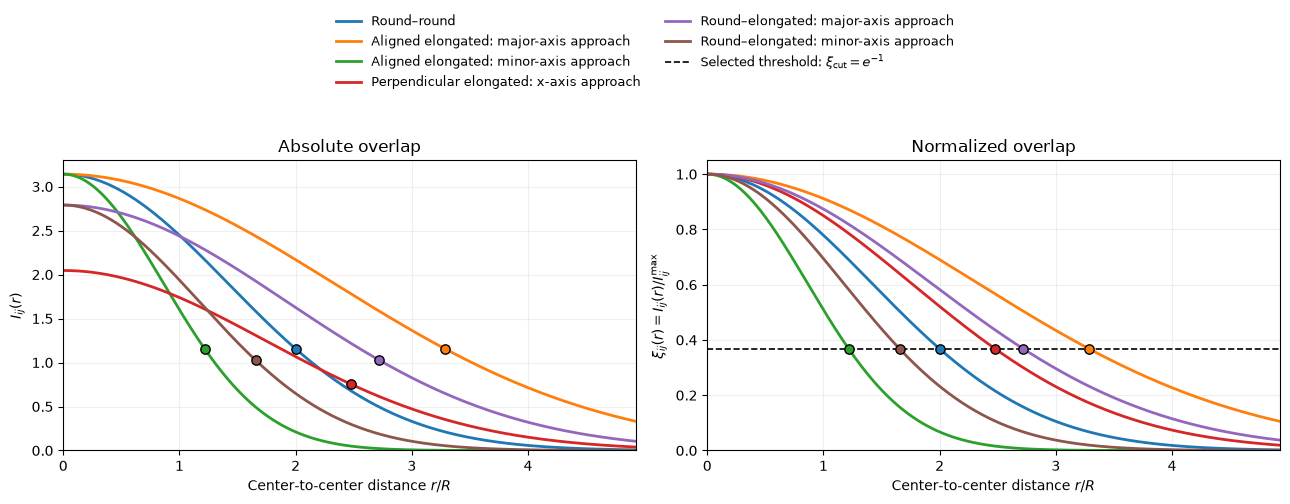

In [5]:
distances = np.linspace(
    0,
    3 * RADIUS * np.sqrt(MAX_ASPECT_RATIO),
    800,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.5),
    sharex=True,
)

curve_handles = []

for index, configuration in enumerate(PAIR_CONFIGURATIONS):
    color = f"C{index}"

    parameters = {
        key: value
        for key, value in configuration.items()
        if key != "label"
    }

    overlap, normalized_overlap, maximum_overlap = pair_overlap(
        distance=distances,
        reference_radius=RADIUS,
        **parameters,
    )

    # Recover q from xi(R) = exp(-q * R**2)
    _, reference_overlap, _ = pair_overlap(
        distance=RADIUS,
        reference_radius=RADIUS,
        **parameters,
    )

    directional_coefficient = (
        -np.log(reference_overlap) / RADIUS**2
    )

    interaction_distance = np.sqrt(
        -np.log(NORMALIZED_OVERLAP_THRESHOLD)
        / directional_coefficient
    )

    # Absolute and normalized overlap at the interaction boundary
    boundary_values = (
        maximum_overlap * NORMALIZED_OVERLAP_THRESHOLD,
        NORMALIZED_OVERLAP_THRESHOLD,
    )

    for panel_index, (ax, values, boundary_value) in enumerate(
        zip(
            axes,
            (overlap, normalized_overlap),
            boundary_values,
        )
    ):
        line, = ax.plot(
            distances / RADIUS,
            values,
            color=color,
            linewidth=2,
            label=configuration["label"],
        )

        if panel_index == 0:
            curve_handles.append(line)

        ax.scatter(
            interaction_distance / RADIUS,
            boundary_value,
            color=color,
            edgecolor="black",
            s=45,
            zorder=5,
        )

threshold_line = axes[1].axhline(
    NORMALIZED_OVERLAP_THRESHOLD,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=r"Selected threshold: $\xi_{\mathrm{cut}}=e^{-1}$",
)

axes[0].set(
    title="Absolute overlap",
    ylabel=r"$I_{ij}(r)$",
    ylim=(0, 1.05 * np.pi * RADIUS**2),
)

axes[1].set(
    title="Normalized overlap",
    ylabel=r"$\xi_{ij}(r)=I_{ij}(r)/I_{ij}^{\max}$",
    ylim=(0, 1.05),
)

for ax in axes:
    ax.set_xlabel(r"Center-to-center distance $r/R$")
    ax.set_xlim(0, distances[-1] / RADIUS)
    ax.grid(alpha=0.2)

fig.legend(
    handles=curve_handles + [threshold_line],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.92),
    ncol=2,
    frameon=False,
    fontsize=9,
)

# fig.suptitle(
#     "Pairwise overlap and selected interaction threshold",
#     fontsize=15,
#     y=0.99,
# )

fig.tight_layout(rect=(0, 0, 1, 0.70))

save_figure(fig, "pairwise_overlap")
plt.show()

## Comparison with geometric contact

We rescale the separation by the contact distance, $r_{\mathrm{contact}}$. The cell contours therefore touch at $r/r_{\mathrm{contact}}=1$.

For the configurations considered here:

- Round–round: $r_{\mathrm{contact}}=2R$.
- Aligned elongated cells: $r_{\mathrm{contact}}=2a$ or $2b$.
- Perpendicular elongated cells approaching along the x axis: $r_{\mathrm{contact}}=a+b$.
- Round–elongated: $r_{\mathrm{contact}}=R+a$ or $R+b$.

Here, $a=R\sqrt{\mathrm{AR}}$ and $b=R/\sqrt{\mathrm{AR}}$ are the major and minor semi-axes.

Circles mark geometric contact; crosses mark the interaction boundary defined by $\xi_{\mathrm{cut}}=e^{-1}$.

In [6]:
major, minor = cell_semiaxes(
    MAX_ASPECT_RATIO,
    reference_radius=RADIUS,
)

CONTACT_DISTANCES = {
    "Round–round": 2 * RADIUS,
    "Aligned elongated: major-axis approach": 2 * major,
    "Aligned elongated: minor-axis approach": 2 * minor,
    "Perpendicular elongated: x-axis approach": major + minor,
    "Round–elongated: major-axis approach": RADIUS + major,
    "Round–elongated: minor-axis approach": RADIUS + minor,
}

scaled_distances = np.linspace(0, 2, 600)
contact_results = {}

for configuration in PAIR_CONFIGURATIONS:
    label = configuration["label"]
    contact_distance = CONTACT_DISTANCES[label]

    parameters = {
        key: value
        for key, value in configuration.items()
        if key != "label"
    }

    _, normalized_overlap, _ = pair_overlap(
        distance=scaled_distances * contact_distance,
        reference_radius=RADIUS,
        **parameters,
    )

    _, normalized_overlap_at_contact, _ = pair_overlap(
        distance=contact_distance,
        reference_radius=RADIUS,
        **parameters,
    )

    # Ratio obtained from xi(r) = exp(-q * r**2)
    cutoff_to_contact_ratio = np.sqrt(
        np.log(NORMALIZED_OVERLAP_THRESHOLD)
        / np.log(normalized_overlap_at_contact)
    )

    contact_results[label] = {
        "curve": normalized_overlap,
        "contact_overlap": float(normalized_overlap_at_contact),
        "cutoff_to_contact_ratio": float(cutoff_to_contact_ratio),
    }

    print(
        f"{label}\n"
        f"  xi at contact: {normalized_overlap_at_contact:.6f}\n"
        f"  r_cut / r_contact: {cutoff_to_contact_ratio:.6f}\n"
    )

Round–round
  xi at contact: 0.367879
  r_cut / r_contact: 1.000000

Aligned elongated: major-axis approach
  xi at contact: 0.367879
  r_cut / r_contact: 1.000000

Aligned elongated: minor-axis approach
  xi at contact: 0.367879
  r_cut / r_contact: 1.000000

Perpendicular elongated: x-axis approach
  xi at contact: 0.437931
  r_cut / r_contact: 1.100501

Round–elongated: major-axis approach
  xi at contact: 0.389030
  r_cut / r_contact: 1.029180

Round–elongated: minor-axis approach
  xi at contact: 0.389030
  r_cut / r_contact: 1.029180



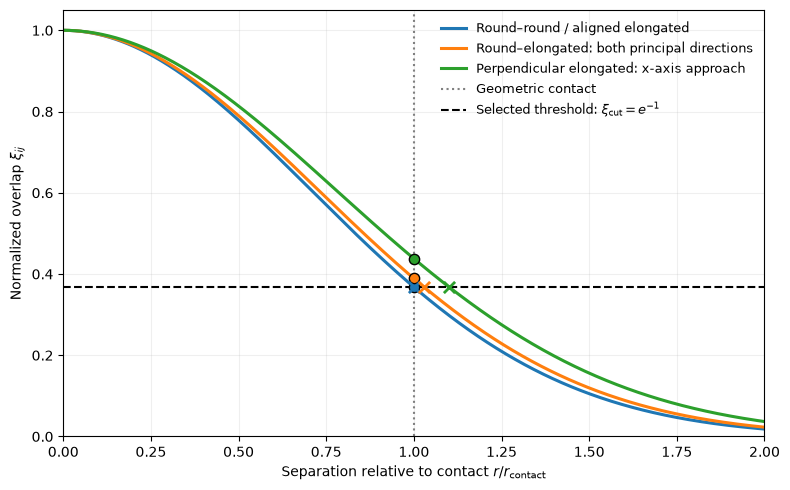

In [7]:
# Group configurations with identical rescaled overlap curves
curve_groups = [
    (
        "Round–round / aligned elongated",
        [
            "Round–round",
            "Aligned elongated: major-axis approach",
            "Aligned elongated: minor-axis approach",
        ],
    ),
    (
        "Round–elongated: both principal directions",
        [
            "Round–elongated: major-axis approach",
            "Round–elongated: minor-axis approach",
        ],
    ),
    (
        "Perpendicular elongated: x-axis approach",
        ["Perpendicular elongated: x-axis approach"],
    ),
]

fig, ax = plt.subplots(figsize=(8, 5))

for index, (group_label, members) in enumerate(curve_groups):
    result = contact_results[members[0]]
    color = f"C{index}"

    # Verify that grouped curves coincide
    for member in members[1:]:
        np.testing.assert_allclose(
            result["curve"],
            contact_results[member]["curve"],
        )

    ax.plot(
        scaled_distances,
        result["curve"],
        color=color,
        linewidth=2.2,
        label=group_label,
    )

    ax.scatter(
        1.0,
        result["contact_overlap"],
        color=color,
        edgecolor="black",
        s=55,
        zorder=5,
    )

    ax.scatter(
        result["cutoff_to_contact_ratio"],
        NORMALIZED_OVERLAP_THRESHOLD,
        color=color,
        marker="x",
        s=65,
        linewidths=2,
        zorder=6,
    )

ax.axvline(
    1.0,
    color="gray",
    linestyle=":",
    label="Geometric contact",
)

ax.axhline(
    NORMALIZED_OVERLAP_THRESHOLD,
    color="black",
    linestyle="--",
    label=r"Selected threshold: $\xi_{\mathrm{cut}}=e^{-1}$",
)

ax.set(
    xlabel=r"Separation relative to contact $r/r_{\mathrm{contact}}$",
    ylabel=r"Normalized overlap $\xi_{ij}$",
    #title="Interaction boundary relative to geometric contact",
    xlim=(0, 2),
    ylim=(0, 1.05),
)

ax.grid(alpha=0.2)
ax.legend(fontsize=9, frameon=False)
fig.tight_layout()

save_figure(fig, "overlap_relative_to_contact")
plt.show()

## Selected criterion

The threshold $\xi_{\mathrm{cut}}=e^{-1}$ reproduces geometric contact for round cells and identical aligned elongated cells.

For the other configurations examined at aspect ratio 2.7, the interaction range extends approximately 3% beyond contact for round–elongated pairs and 10% for perpendicular elongated pairs.

We adopt this threshold as a shape- and orientation-dependent proximity criterion, rather than an exact geometric contact test:

- **Interactions:** a pair interacts when $\xi_{ij}>e^{-1}$.
- **Elongations:** a proposed position and shape are accepted only if every neighboring pair satisfies $\xi_{ij}\leq e^{-1}$.

No additional cutoff based on the sum of major semi-axes is imposed. The spatial grid must provide a sufficiently large candidate search range to include every pair satisfying the interaction criterion.

The contraction safety threshold remains a separate parameter.